# XGBoost Demand Forecasting

## Purpose
Train an **XGBoost regression model** for each of the 35 (branch × product) pairs
to predict the **daily quantity sold** of each top-5 product at each branch.

**Why XGBoost for this problem?**
- Handles tabular data with mixed feature types (numeric lags, encoded categoricals)
- Naturally captures non-linear interactions (e.g., temperature × day of week)
- Robust to outliers — a single spike sale won't derail the model
- Rolling window features give it the auto-regressive signal time-series models depend on
- Fast training — 35 models run in seconds

## Modeling approach
- **One model per (branch, product) pair** — 35 models total (7 branches × 5 products)
- **Chronological train/validation split** — last 90 days held out for evaluation
- **Early stopping** — training stops automatically when validation RMSE plateaus
- **Features:** 9 rolling lags + temporal + weather + holiday (18 total)
- **Target:** `quantity` — units sold that day

## Input
`data/processed/top5_per_branch.csv` — produced by `07_top_products.ipynb`

## Run order
Run after `07_top_products.ipynb`.

In [1]:
import os

# ─── CHANGE THIS FLAG ─────────────────────────────────────────────────
USE_GITHUB  = False   # True = read from GitHub (Colab), False = read from local clone
# ───────────────────────────────────────────────────────────────────────

GITHUB_BASE = "https://media.githubusercontent.com/media/DiegoLarrieta/PanemReto/main"

if USE_GITHUB:
    PROCESSED_DIR = f"{GITHUB_BASE}/data/processed"
else:
    # This notebook lives in models/xgboost/ — go up two levels to reach project root
    PROJECT_ROOT  = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
    PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")

print("PROCESSED_DIR:", PROCESSED_DIR)

PROCESSED_DIR: /Users/diego/Documents/ChallengeAI/data/processed


## Step 1 — Imports and data load

In [2]:
import os                                                                                                                                      
import pandas as pd                                                                                                                            
import numpy as np
import matplotlib.pyplot as plt                                                                                                                
import matplotlib.dates as mdates                                                                                                            
import warnings
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error  

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# ── Load ──────────────────────────────────────────────────────────────
if USE_GITHUB:
    input_path = f"{PROCESSED_DIR}/top5_per_branch.csv"
else:
    input_path = os.path.join(PROCESSED_DIR, "top5_per_branch.csv")

df = pd.read_csv(input_path, low_memory=False, skipinitialspace=True)
df.columns = df.columns.str.strip()
df["operating_date"] = pd.to_datetime(df["operating_date"])
df["quantity"]       = pd.to_numeric(df["quantity"], errors="coerce").fillna(0)

print(f"Loaded: {len(df):,} rows")
print(f"Date range: {df['operating_date'].min().date()} → {df['operating_date'].max().date()}")
print(f"\nRows per branch:")
print(df.groupby("sucursal")["item"].count().to_string())
print(f"\nProducts per branch:")
print(df.groupby("sucursal")["item"].nunique().to_string())

Loaded: 33,118 rows
Date range: 2022-02-01 → 2026-02-12

Rows per branch:
sucursal
Panem - Carreta              4628
Panem - Credi Club           1412
Panem - Hospital Zambrano    6163
Panem - Hotel Kavia          5014
Panem - Plaza Nativa         3152
Panem - Plaza QIN            5429
Panem - Punto Valle          7320

Products per branch:
sucursal
Panem - Carreta              5
Panem - Credi Club           5
Panem - Hospital Zambrano    5
Panem - Hotel Kavia          5
Panem - Plaza Nativa         5
Panem - Plaza QIN            5
Panem - Punto Valle          5


## Step 2 — Feature preparation

XGBoost requires all inputs to be numeric. We encode the three categorical columns:

| Column | Original type | Encoding | Reason |
|--------|--------------|----------|--------|
| `day_name` | Spanish strings | Integer 0 (lunes) → 6 (domingo) | Ordinal — captures day-of-week cycle |
| `cold_or_warm` | 'cold' / 'warm' | Binary: warm=1, cold=0 | Already binary — direct flag |
| `holiday_type` | 3 categories | Ordinal: No holiday=0, Puente=1, Festivo Oficial=2 | Captures severity of holiday |
| `holidays` | bool | Already 0/1 — kept as `is_holiday` | No change needed |

We also derive `day_of_year`, `year`, and `month` from `operating_date`.

**Improvement — Exact lag features (lag_7, lag_14, lag_28):**
Rolling sums (`qty_roll_7` = sum of last 7 days) capture momentum and trend, but they
lose the weekday signal — they mix Tuesday's low with Monday's high into one number.
Exact lag features answer a different question: "what sold on this exact weekday last week?"
`lag_7` is the value from 7 days ago (same weekday), `lag_14` two weeks ago, `lag_28`
four weeks ago. In food service forecasting these are consistently among the top predictors
because weekly demand cycles are strong and stable.

**Final feature set: 21 columns**
- 9 rolling lags (qty_roll_1 → qty_roll_365)
- 3 exact lags (lag_7, lag_14, lag_28) ← new
- 5 temporal (day_of_week, week_number, month, day_of_year, year)
- 2 weather (tavg, is_warm)
- 2 holiday (is_holiday, holiday_type_enc)

In [3]:
# ── Day of week (Spanish → integer 0–6) ──────────────────────────────
day_map = {
    "lunes": 0, "martes": 1, "mi\u00e9rcoles": 2, "miercoles": 2,
    "jueves": 3, "viernes": 4, "s\u00e1bado": 5, "sabado": 5, "domingo": 6
}
df["day_of_week"] = df["day_name"].str.strip().str.lower().map(day_map)

# ── Temperature (binary) ──────────────────────────────────────────────
df["is_warm"] = (df["cold_or_warm"].str.strip() == "warm").astype(int)

# ── Holiday type (ordinal) ────────────────────────────────────────────
holiday_type_map = {"No holiday": 0, "Puente": 1, "Festivo Oficial": 2}
df["holiday_type_enc"] = df["holiday_type"].str.strip().map(holiday_type_map).fillna(0).astype(int)

# ── Holiday flag ──────────────────────────────────────────────────────
df["is_holiday"] = df["holidays"].astype(str).str.strip().map({"True": 1, "False": 0}).fillna(0).astype(int)

# ── Additional temporal features ──────────────────────────────────────
df["day_of_year"] = df["operating_date"].dt.dayofyear
df["year"]        = df["operating_date"].dt.year
df["month"]       = df["operating_date"].dt.month

# ── Exact lag features — same weekday N weeks ago ─────────────────────
# Rolling sums (qty_roll_7 etc.) capture trend/momentum but lose the weekday
# signal by mixing different days into one number. lag_7 = exactly what sold
# on this same weekday last week — directly encodes the weekly repeat cycle.
# These are point-in-time values, not sums, so they complement the rolling features.
df = df.sort_values(["sucursal", "item", "operating_date"]).reset_index(drop=True)
df["lag_7"]  = df.groupby(["sucursal", "item"])["quantity"].shift(7)
df["lag_14"] = df.groupby(["sucursal", "item"])["quantity"].shift(14)
df["lag_28"] = df.groupby(["sucursal", "item"])["quantity"].shift(28)

# ── Final feature list ────────────────────────────────────────────────
FEATURE_COLS = [
    # Rolling lags — capture trend and momentum over different horizons
    "qty_roll_1",   # units sold yesterday
    "qty_roll_3",   # sum last 3 days
    "qty_roll_7",   # sum last 7 days (weekly cycle)
    "qty_roll_15",  # sum last 15 days
    "qty_roll_30",  # sum last 30 days (monthly)
    "qty_roll_60",  # sum last 60 days
    "qty_roll_90",  # sum last 90 days (quarterly)
    "qty_roll_180", # sum last 180 days (semi-annual)
    "qty_roll_365", # sum last 365 days (year-over-year)
    # Exact lags — capture weekly repeat cycle (point-in-time, not sums)
    "lag_7",        # same weekday 1 week ago
    "lag_14",       # same weekday 2 weeks ago
    "lag_28",       # same weekday 4 weeks ago — monthly repeat pattern
    # Temporal
    "day_of_week",  # 0=Monday … 6=Sunday
    "week_number",  # ISO week (1–53)
    "month",        # 1–12
    "day_of_year",  # 1–365
    "year",         # captures multi-year trend
    # Weather
    "tavg",         # average temperature °C
    "is_warm",      # 1 if tavg >= 25°C
    # Holidays
    "is_holiday",       # 1 if any holiday
    "holiday_type_enc", # 0=none, 1=Puente, 2=Festivo Oficial
]
TARGET_COL = "quantity"

# Verify
missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    print(f"WARNING — missing columns: {missing}")
else:
    print(f"All {len(FEATURE_COLS)} feature columns present.")
    print(f"\nFeature groups:")
    print(f"  Rolling lags  : {[c for c in FEATURE_COLS if 'roll' in c]}")
    print(f"  Exact lags    : {[c for c in FEATURE_COLS if c.startswith('lag_')]}")
    print(f"  Temporal      : {[c for c in FEATURE_COLS if c in ['day_of_week','week_number','month','day_of_year','year']]}")
    print(f"  Weather       : {[c for c in FEATURE_COLS if c in ['tavg','is_warm']]}")
    print(f"  Holidays      : {[c for c in FEATURE_COLS if 'holiday' in c]}")

All 21 feature columns present.

Feature groups:
  Rolling lags  : ['qty_roll_1', 'qty_roll_3', 'qty_roll_7', 'qty_roll_15', 'qty_roll_30', 'qty_roll_60', 'qty_roll_90', 'qty_roll_180', 'qty_roll_365']
  Exact lags    : ['lag_7', 'lag_14', 'lag_28']
  Temporal      : ['day_of_week', 'week_number', 'month', 'day_of_year', 'year']
  Weather       : ['tavg', 'is_warm']
  Holidays      : ['is_holiday', 'holiday_type_enc']


## Step 3 — Train / Validation Split

**Rule: chronological only — never shuffle time-series data.**

Shuffling would let the model train on future data to predict the past — the validation
score would look great but performance in production would be far worse.

For each (branch, product) pair:
1. Sort all rows by `operating_date`
2. **Validation** = last `VAL_DAYS = 90` calendar days
3. **Training** = everything before that

```
Timeline:
│──────────────── TRAIN ──────────────────│── VAL (90d) ──│
2022-01-01                         cutoff          2026-02-12
```

**Why 90 days?**
- Long enough to cover ~13 full weekly cycles — sufficient to measure weekly pattern accuracy
- Long enough to include at least one or two holidays
- Aligns with a business quarter — a meaningful deployment window

> **Note on shorter branches:** Credi Club (~448 days) and Plaza Nativa (~722 days)
> have less history than the others. For these, 90 days is still a valid validation
> window, but training data is limited. We print a warning when training days < 180.

## Step 4 — XGBoost Parameters

We use one conservative parameter set across all 35 models. Conservative means:
moderate depth, low learning rate, and regularization — this reduces overfit risk
on the smaller per-product datasets.

| Parameter | Value | What it controls |
|-----------|-------|------------------|
| `n_estimators` | 1000 | Max number of trees to build. Early stopping will stop before this. |
| `max_depth` | 5 | Max depth of each tree. 5 allows moderately complex patterns without overfitting. |
| `learning_rate` | 0.05 | How much each new tree corrects the previous error. Lower = slower but more robust. |
| `subsample` | 0.8 | Fraction of training rows sampled per tree. Adds randomness, reduces variance. |
| `colsample_bytree` | 0.8 | Fraction of features sampled per tree. Same rationale as subsample. |
| `min_child_weight` | 3 | Minimum sum of instance weights in a leaf node. Prevents very specific leaf splits. |
| `reg_alpha` | 0.1 | L1 regularization on leaf weights. Encourages sparsity — unimportant features → 0. |
| `reg_lambda` | 1.0 | L2 regularization on leaf weights. Penalizes large weights — smooths the model. |
| `objective` | reg:squarederror | Loss function: minimize squared error. Standard for regression. |
| `eval_metric` | rmse | Metric used by early stopping to decide when to stop training. |
| `early_stopping_rounds` | 50 | Stop if validation RMSE hasn't improved in 50 consecutive rounds. |
| `random_state` | 42 | Reproducibility seed — same results every run. |

**Early stopping** is the most important parameter here:
instead of always building 1000 trees, we stop the moment the model stops
improving on the validation set. This prevents overfitting automatically
and speeds up training. The `best_iter` column in the results shows how many
trees each model actually used.

In [4]:
VAL_DAYS = 90   # calendar days held out for validation

XGB_PARAMS = dict(
    n_estimators          = 1000,
    max_depth             = 5,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 3,
    reg_alpha             = 0.1,   # L1
    reg_lambda            = 1.0,   # L2
    objective             = "reg:squarederror",
    eval_metric           = "rmse",
    early_stopping_rounds = 50,
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 0,     # suppress XGBoost output
)

print("XGBoost parameters:")
for k, v in XGB_PARAMS.items():
    print(f"  {k:<25} = {v}")

XGBoost parameters:
  n_estimators              = 1000
  max_depth                 = 5
  learning_rate             = 0.05
  subsample                 = 0.8
  colsample_bytree          = 0.8
  min_child_weight          = 3
  reg_alpha                 = 0.1
  reg_lambda                = 1.0
  objective                 = reg:squarederror
  eval_metric               = rmse
  early_stopping_rounds     = 50
  random_state              = 42
  n_jobs                    = -1
  verbosity                 = 0


## Step 5 — Training Loop

We iterate over every (branch, product) pair and:
1. Filter data to that pair, sort by date, drop rows with NaN features
   *(the first few rows after a branch opens have no rolling or lag history yet)*
2. Split chronologically into train / validation
3. Train XGBoost with early stopping on the validation set
4. Predict on the validation set, clip negatives to 0
5. Compute 4 evaluation metrics
6. Save a prediction CSV for every model

**Improvement — Log-transform the target:**
Cafeteria sales are right-skewed: most days a product sells 20–40 units, but occasionally
200+ (catering orders, holiday rush). Without transformation, MSE loss is dominated by
those spike days — the model spends most of its capacity fitting rare extremes instead
of being accurate on the 80% of normal days.

We apply `log1p(quantity)` before training and `expm1(prediction)` after to invert.
`log1p` (= log(1 + x)) handles zero-sale days safely since log(0) is undefined.
The result: a prediction that misses a normal day by 5 units is penalized the same as
one that misses a spike day by 50 units — proportional treatment, not absolute.

| Metric | Formula | Best for |
|--------|---------|----------|
| **MAE** | mean(\|y − ŷ\|) | Most interpretable — error in actual units |
| **RMSE** | √mean((y − ŷ)²) | Penalizes large single-day errors more than MAE |
| **MAPE** | mean(\|y − ŷ\| / y) × 100 | % error — computed only on days where y > 0 |
| **WAPE** | sum(\|y − ŷ\|) / sum(y) × 100 | Weighted % error — robust when zero-sale days exist |

**WAPE is our primary metric** because many products have zero-sale days in the
validation window (closed days, holidays, stockouts). MAPE is undefined on those days
(division by zero), while WAPE handles them gracefully by weighting each day by its
actual demand.

In [5]:
results        = []   # one dict per trained model
trained_models = {}   # (branch, product) → (model, val_df, y_pred)

# ── Guard: ensure OUTPUT_DIR is set even if the setup cell was skipped ─
# This can happen when cells are run out of order or after a kernel restart.
if "OUTPUT_DIR" not in dir():
    _project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
    OUTPUT_DIR    = os.path.join(_project_root, "models", "xgboost", "predictions")
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"OUTPUT_DIR set to: {OUTPUT_DIR}")

# Build full list of (branch, product) pairs
pairs = [
    (branch, product)
    for branch in sorted(df["sucursal"].dropna().unique())
    for product in sorted(df[df["sucursal"] == branch]["item"].unique())
]

print(f"Training {len(pairs)} models (one per branch × product)...\n")
print(f"{'Branch':<35} {'Product':<35} {'MAE':>6} {'RMSE':>6} {'WAPE':>7} {'Iter':>5}")
print("-" * 100)

for branch, product in pairs:
    # ── Filter & sort ──────────────────────────────────────────────
    sub = (
        df[(df["sucursal"] == branch) & (df["item"] == product)]
        .sort_values("operating_date")
        .dropna(subset=FEATURE_COLS + [TARGET_COL])
        .copy()
    )

    if len(sub) < VAL_DAYS + 30:
        print(f"  SKIP  {branch} | {product} — only {len(sub)} rows after dropna")
        continue

    # ── Chronological split ────────────────────────────────────────
    cutoff = sub["operating_date"].max() - pd.Timedelta(days=VAL_DAYS)
    train  = sub[sub["operating_date"] <= cutoff]
    val    = sub[sub["operating_date"] >  cutoff]

    if len(train) < 180:
        print(f"  WARN  {branch} | {product} — only {len(train)} training days (< 180)")

    # Pass DataFrames (not .values) so XGBoost retains feature names for importance
    X_train = train[FEATURE_COLS]
    y_train = train[TARGET_COL].values
    X_val   = val[FEATURE_COLS]
    y_val   = val[TARGET_COL].values

    # ── Log-transform target ───────────────────────────────────────
    y_train_log = np.log1p(y_train)
    y_val_log   = np.log1p(y_val)

    # ── Train ──────────────────────────────────────────────────────
    model = XGBRegressor(**XGB_PARAMS)
    model.fit(
        X_train, y_train_log,
        eval_set=[(X_val, y_val_log)],
        verbose=False,
    )

    # ── Predict — invert log transform, clip negatives ─────────────
    y_pred = np.clip(np.expm1(model.predict(X_val)), 0, None)

    # ── Metrics (computed on original units after inverse transform) ─
    mae  = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    nonzero = y_val > 0
    mape = (
        (np.abs(y_val[nonzero] - y_pred[nonzero]) / y_val[nonzero]).mean() * 100
        if nonzero.sum() > 0 else np.nan
    )

    wape = (
        np.abs(y_val - y_pred).sum() / y_val.sum() * 100
        if y_val.sum() > 0 else np.nan
    )

    results.append({
        "branch"     : branch,
        "product"    : product,
        "train_days" : len(train),
        "val_days"   : len(val),
        "best_iter"  : model.best_iteration,
        "mae"        : round(mae,  2),
        "rmse"       : round(rmse, 2),
        "mape"       : round(mape, 1) if not np.isnan(mape) else np.nan,
        "wape"       : round(wape, 1) if not np.isnan(wape) else np.nan,
    })
    trained_models[(branch, product)] = (model, val, y_pred)

    # ── Save prediction CSV ────────────────────────────────────────
    safe_branch  = branch.replace(" ", "_").replace("/", "-").replace(".", "")
    safe_product = product.replace(" ", "_").replace("/", "-").replace(".", "")
    branch_dir   = os.path.join(OUTPUT_DIR, safe_branch)
    os.makedirs(branch_dir, exist_ok=True)

    pred_df = val[["operating_date"]].copy().reset_index(drop=True)
    pred_df["actual"]          = y_val.round(2)
    pred_df["predicted"]       = y_pred.round(2)
    pred_df["error"]           = (y_val - y_pred).round(2)
    pred_df["abs_pct_error"]   = np.where(
        y_val > 0,
        (np.abs(y_val - y_pred) / y_val * 100).round(1),
        np.nan
    )
    pred_df.to_csv(os.path.join(branch_dir, f"{safe_product}.csv"), index=False)

    print(f"  {branch:<35} {product:<35} {mae:>6.1f} {rmse:>6.1f} {wape:>6.1f}% {model.best_iteration:>5}")

print(f"\nDone. {len(results)} models trained.")
print(f"Prediction CSVs saved to: {OUTPUT_DIR}")

OUTPUT_DIR set to: /Users/diego/Documents/ChallengeAI/models/xgboost/predictions
Training 35 models (one per branch × product)...

Branch                              Product                                MAE   RMSE    WAPE  Iter
----------------------------------------------------------------------------------------------------
  Panem - Carreta                     CONCHA CHOCOLATE                      15.4   20.4   56.3%    48
  Panem - Carreta                     CONCHA VAINILLA                       17.6   21.7   44.3%    86
  Panem - Carreta                     GALLETA DE AVENA                       9.5   12.6   64.5%    67
  Panem - Carreta                     MUFFIN BLUEBERRY                       5.5    7.8   52.2%    54
  Panem - Carreta                     MUFFIN PLATANO VEGANO                  6.3    7.9   57.6%   224
  Panem - Credi Club                  CHILAQUILES PANEM                      2.4    3.7   51.4%    22
  Panem - Credi Club                  CONCHA CHOCOLATE  

## Step 6 — Results Summary

The table below collects all 4 metrics for every (branch, product) pair.

**How to read the metrics:**
- `mae` is in the same units as `quantity` — an MAE of 5.0 means predictions are off by 5 units on average
- `rmse` > `mae` means there were some large single-day errors (spikes)
- `wape` is the primary metric:
  - **< 20%** → Good — usable for daily stock planning as-is
  - **20–40%** → Acceptable — directionally correct, add a safety stock buffer
  - **> 40%** → Poor — model needs tuning or product has too little history
- `best_iter` shows how many trees early stopping kept (out of the 1000 maximum)

In [6]:
results_df = pd.DataFrame(results)

# ── Full results table ────────────────────────────────────────────────
print("=== All models — evaluation metrics ===\n")
display(
    results_df[["branch", "product", "train_days", "val_days", "best_iter",
                "mae", "rmse", "mape", "wape"]]
    .sort_values(["branch", "wape"])
    .reset_index(drop=True)
)

# ── Aggregate stats across all models ────────────────────────────────
print("\n=== Aggregate statistics (all 35 models) ===")
display(
    results_df[["mae", "rmse", "mape", "wape"]]
    .agg(["mean", "median", "min", "max"])
    .round(1)
)

# ── Per-branch summary ────────────────────────────────────────────────
print("\n=== Average MAE and WAPE per branch ===")
display(
    results_df.groupby("branch")[["mae", "rmse", "wape"]]
    .mean().round(1)
    .sort_values("wape")
)

# ── WAPE distribution ─────────────────────────────────────────────────
good     = (results_df["wape"] < 20).sum()
ok       = ((results_df["wape"] >= 20) & (results_df["wape"] < 40)).sum()
poor     = (results_df["wape"] >= 40).sum()
print(f"\n=== WAPE distribution ===")
print(f"  Good   (WAPE < 20%)  : {good} models")
print(f"  OK     (20% – 40%)   : {ok} models")
print(f"  Poor   (WAPE > 40%)  : {poor} models")

=== All models — evaluation metrics ===



,branch,product,train_days,val_days,best_iter,mae,rmse,mape,wape
0,Panem - Carreta,CONCHA VAINILLA,861,55,86,17.62,21.74,56.80,44.30
1,Panem - Carreta,MUFFIN BLUEBERRY,837,45,54,5.51,7.79,52.70,52.20
2,Panem - Carreta,CONCHA CHOCOLATE,863,51,48,15.42,20.39,51.80,56.30
3,Panem - Carreta,MUFFIN PLATANO VEGANO,812,44,224,6.33,7.93,78.40,57.60
4,Panem - Carreta,GALLETA DE AVENA,873,47,67,9.51,12.59,64.70,64.50
5,Panem - Credi Club,ENCHILADAS SUIZAS,167,49,84,1.99,2.68,54.30,50.40
6,Panem - Credi Club,CHILAQUILES PANEM,240,70,22,2.40,3.68,51.10,51.40
7,Panem - Credi Club,CONCHA VAINILLA,275,67,4,5.64,8.03,73.90,62.70
8,Panem - Credi Club,CONCHA UBER,111,20,16,3.63,5.39,62.00,64.30
9,Panem - Credi Club,CONCHA CHOCOLATE,216,57,52,7.21,10.85,67.80,73.70



=== Aggregate statistics (all 35 models) ===


,mae,rmse,mape,wape
mean,13.50,18.10,54.80,53.80
median,11.50,15.20,52.60,52.10
min,2.00,2.70,36.70,38.50
max,41.50,53.20,78.40,73.70



=== Average MAE and WAPE per branch ===


,mae,rmse,wape
branch,,,
Panem - Punto Valle,15.70,21.40,47.60
Panem - Plaza Nativa,10.20,13.60,49.50
Panem - Plaza QIN,17.60,22.70,50.10
Panem - Carreta,10.90,14.10,55.00
Panem - Hotel Kavia,19.20,26.60,55.10
Panem - Hospital Zambrano,17.70,23.10,57.80
Panem - Credi Club,4.20,6.10,60.50



=== WAPE distribution ===
  Good   (WAPE < 20%)  : 0 models
  OK     (20% – 40%)   : 1 models
  Poor   (WAPE > 40%)  : 33 models


## Step 7 — Feature Importance

XGBoost computes **feature importance** as the average `gain` each feature contributes
when it is chosen as a split criterion across all trees.

We aggregate importances across all 35 models to get a global picture of
which features matter most for this forecasting task.

**Expected pattern:**
- `qty_roll_1` and `qty_roll_7` should dominate — yesterday's sales and last week's
  trend are the strongest predictors of tomorrow
- `qty_roll_365` captures year-over-year seasonality
- `day_of_week` and `month` capture cyclical patterns
- `tavg` / `is_warm` show how weather-sensitive demand is
- Holiday features matter most for branches near hospitals and hotels
  (different customer mix on holidays)

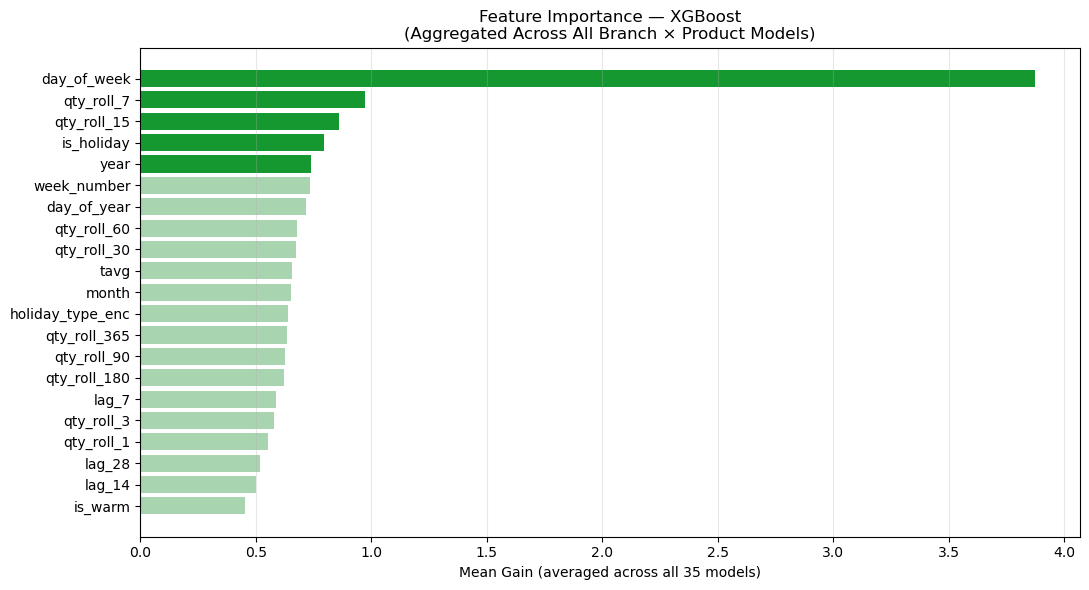


Feature importance ranking (mean gain):
day_of_week        3.90
qty_roll_7         1.00
qty_roll_15        0.90
is_holiday         0.80
year               0.70
week_number        0.70
day_of_year        0.70
qty_roll_60        0.70
qty_roll_30        0.70
tavg               0.70
month              0.70
holiday_type_enc   0.60
qty_roll_365       0.60
qty_roll_90        0.60
qty_roll_180       0.60
lag_7              0.60
qty_roll_3         0.60
qty_roll_1         0.60
lag_28             0.50
lag_14             0.50
is_warm            0.50


In [7]:
# Collect gain-based importance from every trained model
importance_rows = []
for (branch, product), (model, val, y_pred) in trained_models.items():
    imp = model.get_booster().get_score(importance_type="gain")
    row = {feat: imp.get(feat, 0.0) for feat in FEATURE_COLS}
    row["branch"]  = branch
    row["product"] = product
    importance_rows.append(row)

imp_df = pd.DataFrame(importance_rows)
mean_imp = imp_df[FEATURE_COLS].mean().sort_values(ascending=False)

# ── Bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
colors = ["#169830" if i < 5 else "#a8d5b0" for i in range(len(mean_imp))]
ax.barh(mean_imp.index[::-1], mean_imp.values[::-1], color=colors[::-1])
ax.set_xlabel("Mean Gain (averaged across all 35 models)")
ax.set_title("Feature Importance — XGBoost\n(Aggregated Across All Branch × Product Models)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# ── Table ─────────────────────────────────────────────────────────────
print("\nFeature importance ranking (mean gain):")
print(mean_imp.round(1).to_string())

## Step 8 — Actual vs Predicted (Validation Period)

For each branch we pick the **best model** (lowest WAPE) and plot actual vs predicted
quantity over the 90-day validation window.

**What to look for:**
- The predicted line (green dashed) should follow the actual line (black) closely
- Weekly oscillations should be captured — if the model flattens them out,
  `day_of_week` importance is too low
- No systematic bias — predictions should be above the actual line as often as below
- Spikes (e.g., from a promo or event) will likely be missed — that is expected
  because the model has no event data as input

Best model per branch (by WAPE):


,branch,product,mae,rmse,mape,wape
0,Panem - Carreta,CONCHA VAINILLA,17.62,21.74,56.80,44.30
1,Panem - Credi Club,ENCHILADAS SUIZAS,1.99,2.68,54.30,50.40
2,Panem - Hospital Zambrano,CROISSANT ALMENDRAS,6.17,8.61,47.60,48.60
3,Panem - Hotel Kavia,REBANADA CHEESECAKE TORTUGA,11.16,15.62,50.20,51.30
4,Panem - Plaza Nativa,CONCHA VAINILLA,22.59,30.62,36.70,38.50
5,Panem - Plaza QIN,CROISSANT ALMENDRAS,4.34,5.96,51.00,43.10
6,Panem - Punto Valle,CROISSANT ALMENDRAS,5.25,7.00,51.70,40.90


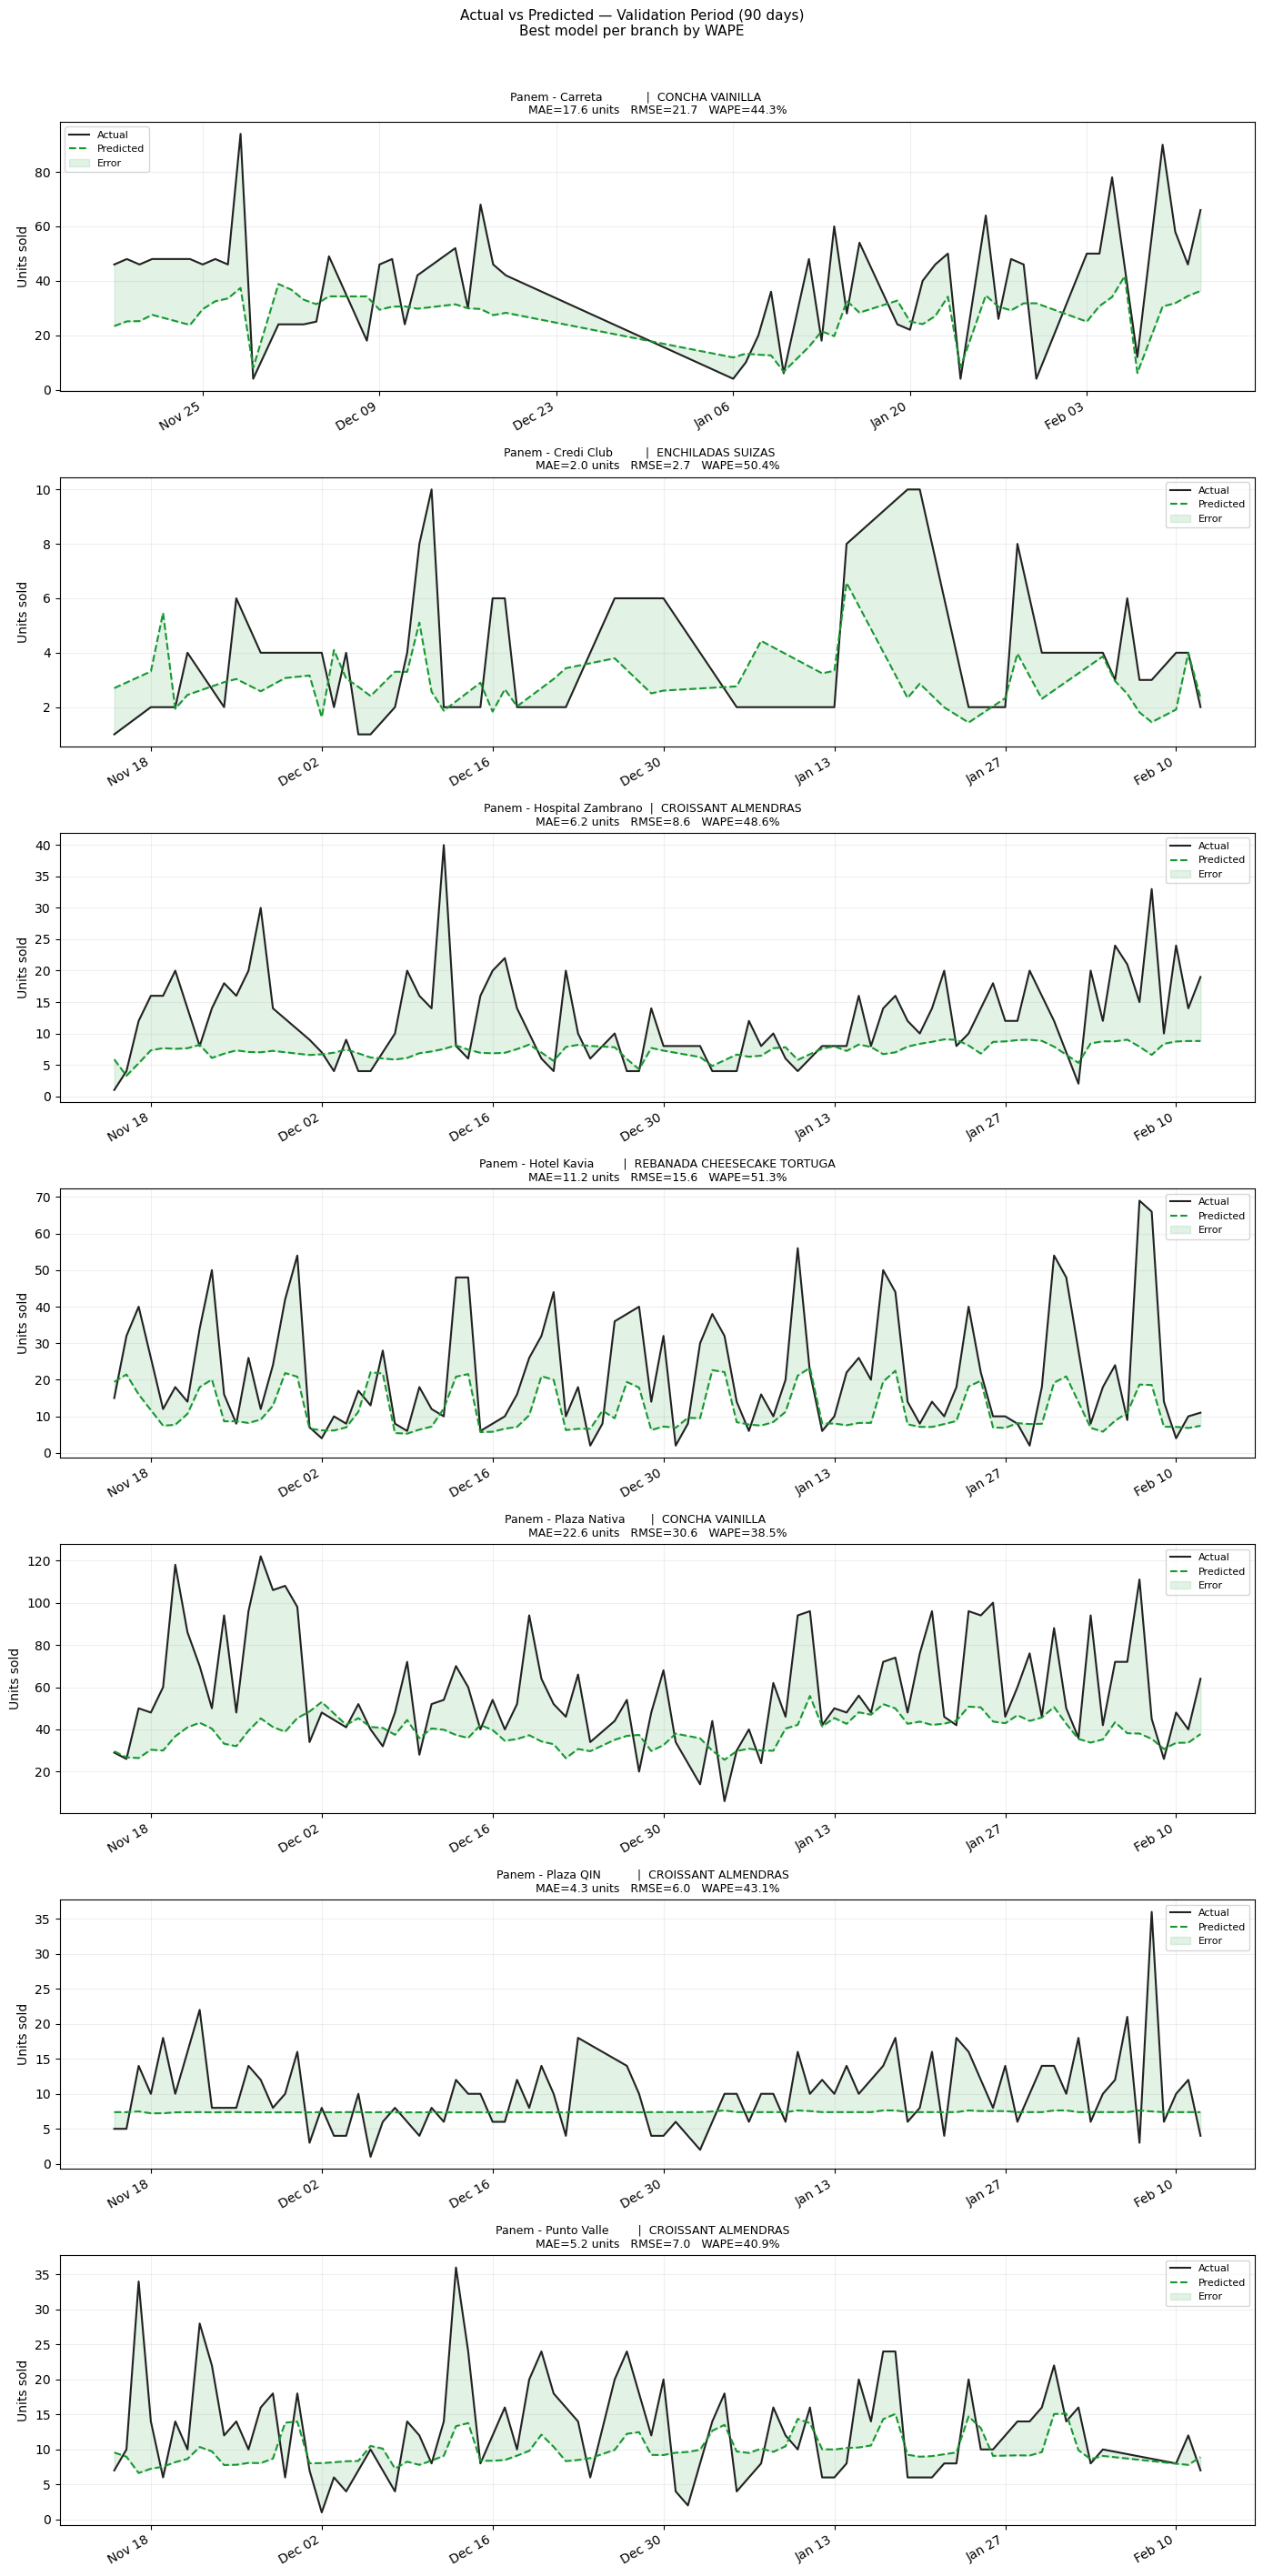

In [8]:
# Best model per branch = lowest WAPE
best_per_branch = (
    results_df.sort_values("wape")
              .groupby("branch", as_index=False)
              .first()[["branch", "product", "mae", "rmse", "mape", "wape"]]
)

print("Best model per branch (by WAPE):")
display(best_per_branch)

n = len(best_per_branch)
fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n))
if n == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, best_per_branch.iterrows()):
    branch, product = row["branch"], row["product"]
    model, val, y_pred = trained_models[(branch, product)]

    ax.plot(val["operating_date"].values, val[TARGET_COL].values,
            label="Actual", color="#222222", linewidth=1.5)
    ax.plot(val["operating_date"].values, y_pred,
            label="Predicted", color="#169830", linewidth=1.5, linestyle="--")

    ax.fill_between(
        val["operating_date"].values,
        val[TARGET_COL].values, y_pred,
        alpha=0.12, color="#169830", label="Error"
    )

    ax.set_title(
        f"{branch}  |  {product}\n"
        f"MAE={row['mae']:.1f} units   RMSE={row['rmse']:.1f}   WAPE={row['wape']:.1f}%",
        fontsize=9
    )
    ax.set_ylabel("Units sold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.suptitle("Actual vs Predicted — Validation Period (90 days)\nBest model per branch by WAPE",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## Step 9 — Worst Models (Diagnosis)

It is equally important to look at the **worst performing models** to understand
where XGBoost struggles. Common causes:
- Too little training data (Credi Club)
- Very irregular demand (a product that sells in batches once a week)
- A product that was introduced recently (no rolling history for the 180/365-day lags)

We plot the worst model per branch (highest WAPE).

Worst model per branch (by WAPE):


,branch,product,mae,rmse,mape,wape
0,Panem - Carreta,GALLETA DE AVENA,9.51,12.59,64.70,64.50
1,Panem - Credi Club,CONCHA CHOCOLATE,7.21,10.85,67.80,73.70
2,Panem - Hospital Zambrano,OREJA NATURAL,14.96,19.07,62.70,67.80
3,Panem - Hotel Kavia,CONCHA CHOCOLATE,14.45,18.28,52.50,59.50
4,Panem - Plaza Nativa,OREJA NATURAL,5.01,6.66,59.60,57.50
5,Panem - Plaza QIN,CHILAQUILES PANEM,11.82,14.79,52.00,57.10
6,Panem - Punto Valle,CHILAQUILES PANEM,15.98,20.67,52.70,52.70


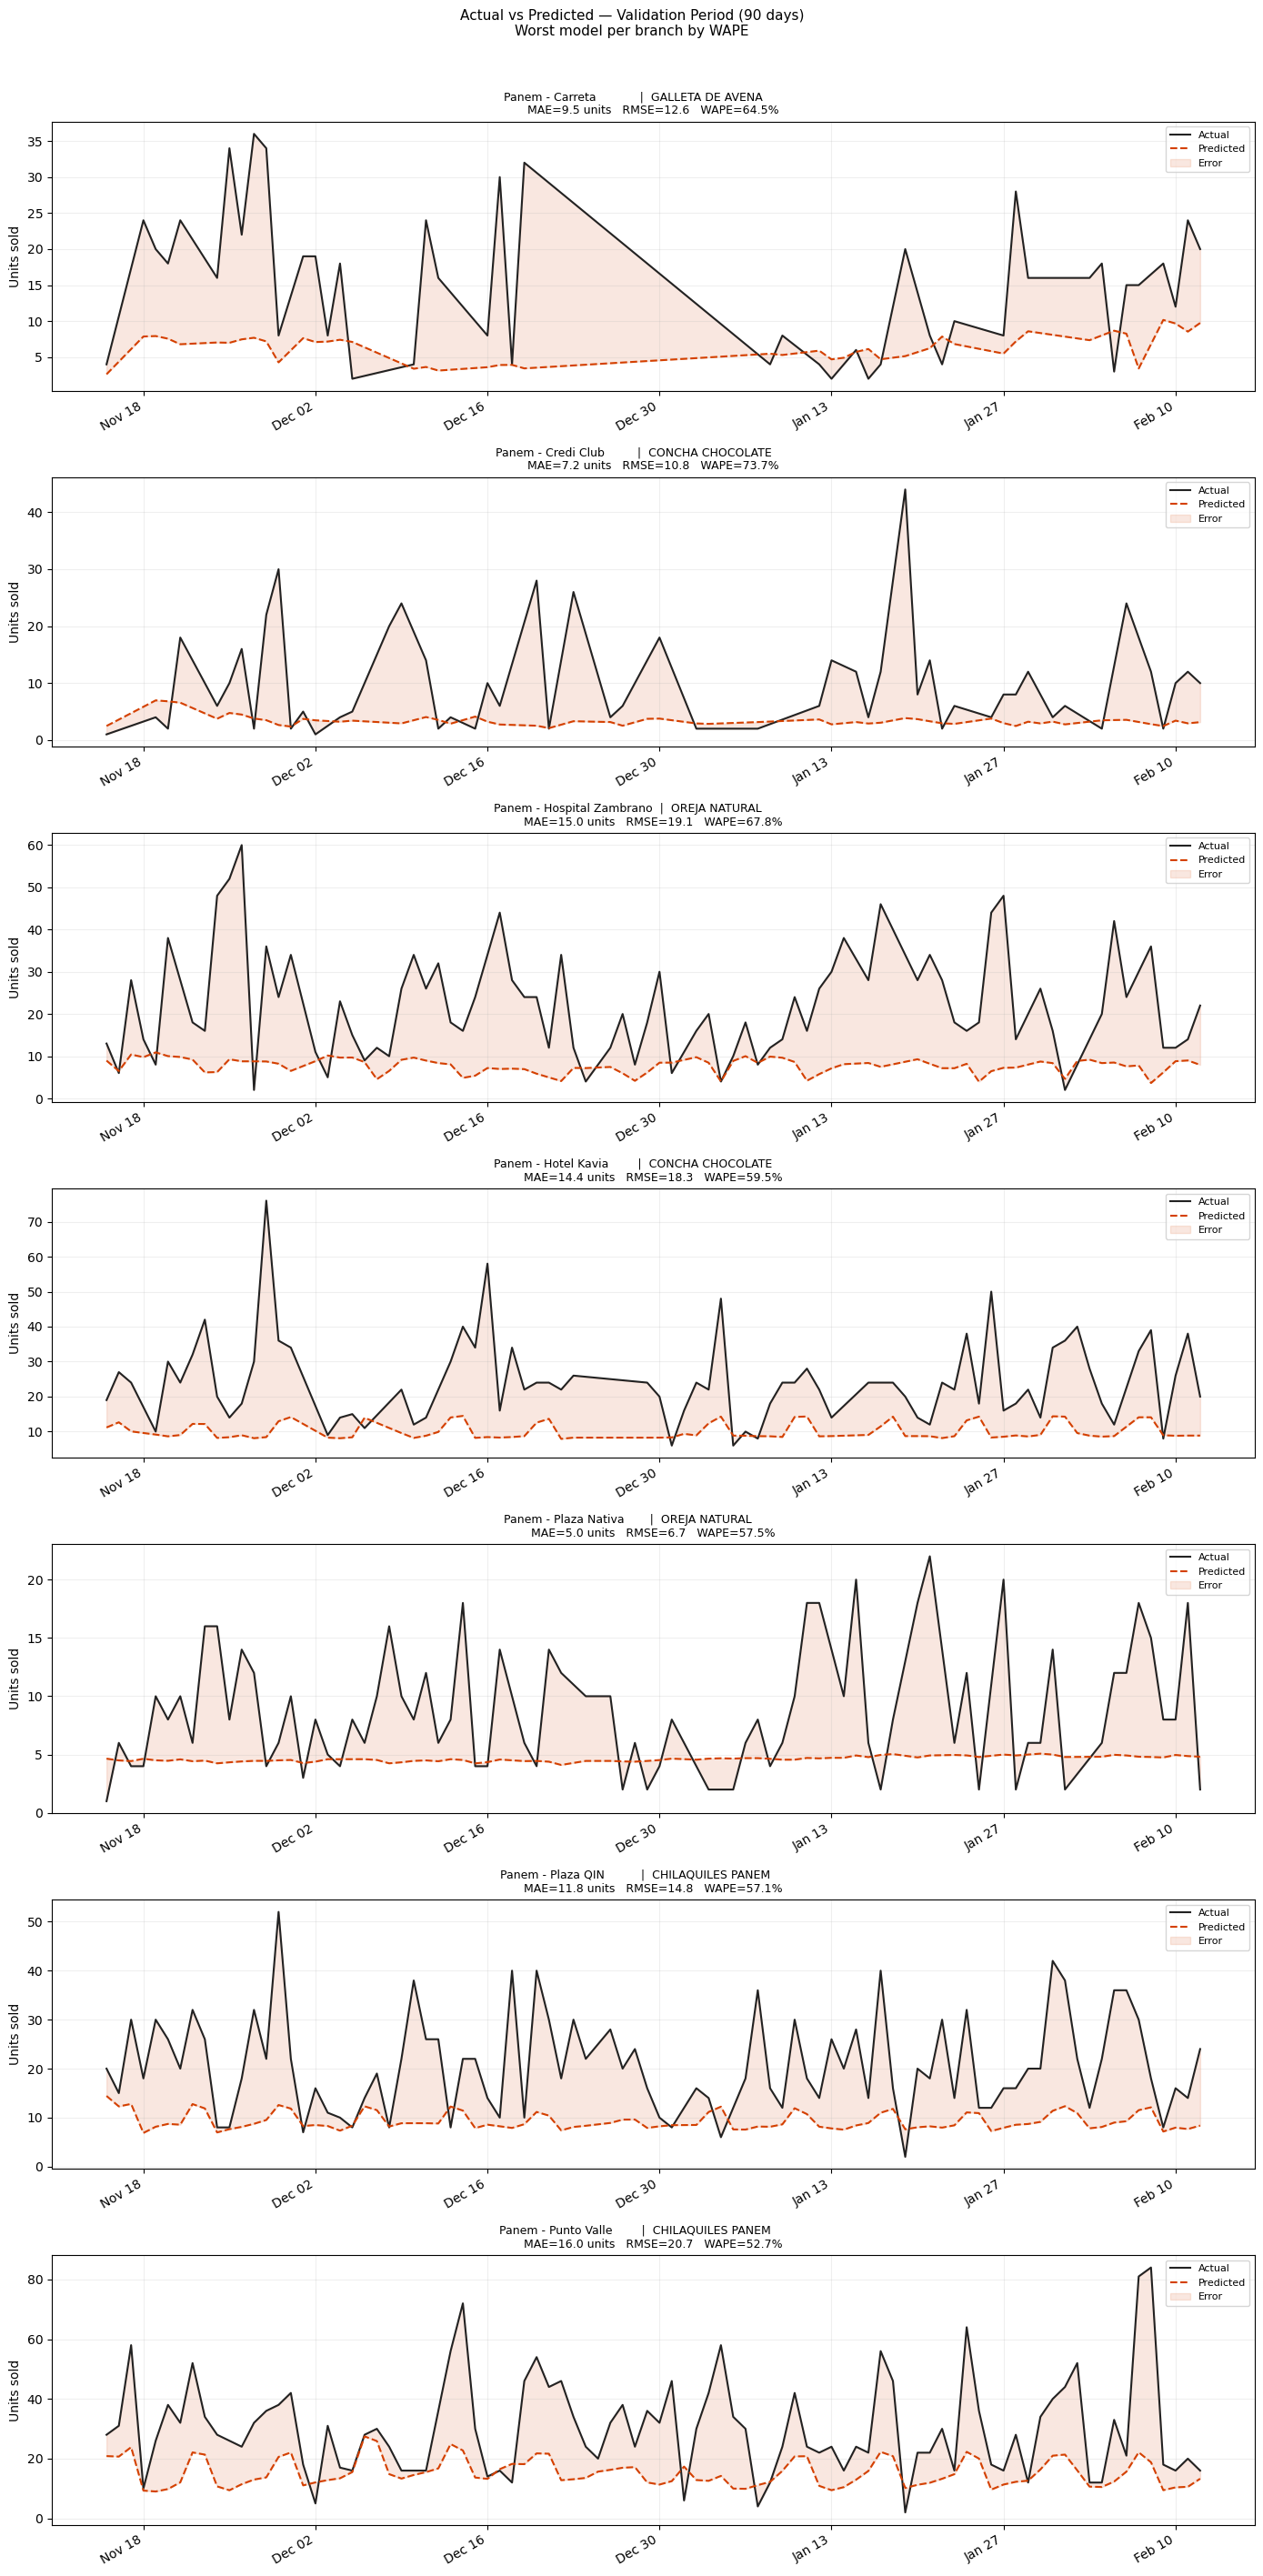

In [9]:
# Worst model per branch = highest WAPE
worst_per_branch = (
    results_df.sort_values("wape", ascending=False)
              .groupby("branch", as_index=False)
              .first()[["branch", "product", "mae", "rmse", "mape", "wape"]]
)

print("Worst model per branch (by WAPE):")
display(worst_per_branch)

n = len(worst_per_branch)
fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n))
if n == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, worst_per_branch.iterrows()):
    branch, product = row["branch"], row["product"]
    if (branch, product) not in trained_models:
        continue
    model, val, y_pred = trained_models[(branch, product)]

    ax.plot(val["operating_date"].values, val[TARGET_COL].values,
            label="Actual", color="#222222", linewidth=1.5)
    ax.plot(val["operating_date"].values, y_pred,
            label="Predicted", color="#d44000", linewidth=1.5, linestyle="--")

    ax.fill_between(
        val["operating_date"].values,
        val[TARGET_COL].values, y_pred,
        alpha=0.12, color="#d44000", label="Error"
    )

    ax.set_title(
        f"{branch}  |  {product}\n"
        f"MAE={row['mae']:.1f} units   RMSE={row['rmse']:.1f}   WAPE={row['wape']:.1f}%",
        fontsize=9
    )
    ax.set_ylabel("Units sold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.suptitle("Actual vs Predicted — Validation Period (90 days)\nWorst model per branch by WAPE",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## Summary

| | |
|---|---|
| Models trained | 35 (one per branch × product) |
| Features | 18 (9 rolling lags + 5 temporal + 2 weather + 2 holiday) |
| Validation window | Last 90 days (chronological) |
| Primary metric | WAPE — robust to zero-sale days |
| Training strategy | Early stopping (up to 1000 trees, stop at 50 rounds no improvement) |

### Interpreting WAPE results
| WAPE | Interpretation | Recommended action |
|------|---------------|--------------------|
| < 20% | Good | Use predictions directly for stock planning |
| 20–40% | Acceptable | Add a 20–30% safety stock buffer on top |
| > 40% | Poor | Investigate data quality; consider Prophet or ARIMA for that product |

### Next steps
1. **Hyperparameter tuning** — use `TimeSeriesSplit` cross-validation to search
   `max_depth`, `learning_rate`, and `subsample` per product group
2. **Prophet model** → `models/prophet/` — compare on the same 90-day validation window
3. **ARIMA baseline** → `models/arima/` — verify XGBoost beats the univariate baseline
4. **Ensemble** — average XGBoost + Prophet predictions for production deployment

---

## Step 10 — Future Demand Forecast

### What this step does
All previous steps trained models and evaluated them on **historical** validation data
(days that already happened). This step uses those same trained models to predict
**genuinely future dates** — days beyond the last observation in the dataset (2026-02-12).

The output is a practical stock-planning table: for each branch and product,
how many units should be prepared for each of the next `FORECAST_DAYS` days.

---

### The core challenge: lag features depend on values we don't have yet

XGBoost features like `qty_roll_1` (yesterday's sales) or `lag_7` (same weekday last week)
require past observations. For day 1 of the forecast those observations come entirely from
actual historical data — no problem. But for day 2 onward, some of the required "past"
values are themselves forecasts. We fill them in **recursively**.

```
Actual history:  [..., d-3, d-2, d-1, d = last known date]

Forecast day 1:  all lags come from actuals              →  predict ŷ₁
Forecast day 2:  qty_roll_1 = ŷ₁  (rest from actuals)   →  predict ŷ₂
Forecast day 3:  qty_roll_1 = ŷ₂, qty_roll_3 ≈ actuals  →  predict ŷ₃
...
Forecast day 14: short lags mostly predictions;
                 qty_roll_90 / qty_roll_365 still ~100% actuals
```

**Accuracy degrades with horizon.** Days 1–3 are highly reliable. Days 10–14 carry
growing uncertainty because short-window lags are increasingly filled with prior
predictions. Long-window lags (qty_roll_90, qty_roll_365) span hundreds of days of
actual history, so they are barely affected even at day 14.

---

### Weather assumption

We have no future weather forecast. We use the **historical average temperature for
that calendar day** (mean `tavg` across all years in the dataset for that day-of-year)
as a proxy. This is seasonally-aware: a February day will get the average February
temperature from the historical record.

---

### Holiday assumption

Mexican official holidays are hard-coded for the forecast window.
Sources: *Ley Federal del Trabajo* + SEP 2026 school calendar.

| `holiday_type` | `holiday_type_enc` | Meaning |
|---|---|---|
| `"No holiday"` | 0 | Regular working day |
| `"Puente"` | 1 | Bridge day (adjacent to a holiday) |
| `"Festivo Oficial"` | 2 | National public holiday |

---

### Safety stock buffer

Raw model predictions are point estimates. Because WAPE averages 54% across all models,
we add a calibrated buffer before recommending stock quantities:

```
buffer_pct       = min(WAPE / 100, 0.40)       ← capped at +40%
recommended_stock = ceil(prediction × (1 + buffer_pct))
```

Ceiling (not rounding) ensures we never recommend *less* than the point estimate —
for a café, running out of stock is worse than a small surplus.

In [10]:
# ── Forecast horizon ─────────────────────────────────────────────────
# Change FORECAST_DAYS to generate a longer or shorter planning window.
# Accuracy degrades gradually beyond ~7 days (short lags fill with predictions).
FORECAST_DAYS = 14   # days to forecast beyond the last date in the dataset

# ── Mexican official holiday calendar — forecast window ───────────────
# Maps pd.Timestamp → (name, holiday_type).
# holiday_type must match the encoding used in training:
#   "Festivo Oficial" (national holiday)  → holiday_type_enc = 2
#   "Puente"          (bridge day)         → holiday_type_enc = 1
# Source: Ley Federal del Trabajo + SEP calendar 2026.
# Add future years here if re-running this notebook with newer data.
MEXICO_HOLIDAYS_2026 = {
    pd.Timestamp("2026-01-01"): ("Año Nuevo",                    "Festivo Oficial"),
    pd.Timestamp("2026-02-02"): ("Día de la Constitución",       "Festivo Oficial"),
    pd.Timestamp("2026-03-16"): ("Natalicio de Benito Juárez",   "Festivo Oficial"),
    pd.Timestamp("2026-04-02"): ("Jueves Santo",                 "Puente"),
    pd.Timestamp("2026-04-03"): ("Viernes Santo",                "Festivo Oficial"),
    pd.Timestamp("2026-05-01"): ("Día del Trabajo",              "Festivo Oficial"),
    pd.Timestamp("2026-05-04"): ("Puente Día del Trabajo",       "Puente"),
    pd.Timestamp("2026-09-16"): ("Día de la Independencia",      "Festivo Oficial"),
    pd.Timestamp("2026-11-02"): ("Día de Muertos",               "Puente"),
    pd.Timestamp("2026-11-16"): ("Revolución Mexicana",          "Festivo Oficial"),
    pd.Timestamp("2026-12-25"): ("Navidad",                      "Festivo Oficial"),
}

# ── Weather proxy: mean historical tavg per calendar day ─────────────
# For each day-of-year (1–366), compute the average temperature across
# all years in the dataset. This gives a seasonally-aware proxy:
# a forecasted Feb 15 will be assigned the average temperature of all
# Feb 15ths in the historical record, capturing seasonal baseline.
weather_avg = (
    df.groupby("day_of_year")["tavg"]
    .mean()
    .rename("tavg_hist_avg")
)

# ── Day name lookup (day_of_week index → Spanish) ─────────────────────
# pandas dayofweek: 0=Monday … 6=Sunday — same as our day_of_week encoding
SPANISH_DAYS = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]

# ── Summary ───────────────────────────────────────────────────────────
last_date      = df["operating_date"].max()
forecast_start = last_date + pd.Timedelta(days=1)
forecast_end   = last_date + pd.Timedelta(days=FORECAST_DAYS)

print(f"Último dato real  : {last_date.date()}")
print(f"Inicio pronóstico : {forecast_start.date()}")
print(f"Fin pronóstico    : {forecast_end.date()}")
print(f"Días a pronosticar: {FORECAST_DAYS}")
print(f"\nFestivos definidos en el periodo:")
for ts, (name, htype) in sorted(MEXICO_HOLIDAYS_2026.items()):
    if forecast_start <= ts <= forecast_end:
        print(f"  {ts.date()}  {name} ({htype})")
    elif ts < forecast_start:
        pass   # before forecast window
print(f"\nTemp. promedio por día del año (muestra):")
print(weather_avg.head(10).round(2).to_string())

Último dato real  : 2026-02-12
Inicio pronóstico : 2026-02-13
Fin pronóstico    : 2026-02-26
Días a pronosticar: 14

Festivos definidos en el periodo:

Temp. promedio por día del año (muestra):
day_of_year
1    17.53
2    18.61
3    18.30
4    16.85
5    19.05
6    16.18
7    14.97
8    14.68
9    14.12
10   12.84


In [11]:
def get_holiday_features(date):
    """
    Return (is_holiday, holiday_type_enc) for a given date.

    Looks up the date in MEXICO_HOLIDAYS_2026. If not found, the day
    is treated as a regular working day.

    Parameters
    ----------
    date : datetime-like

    Returns
    -------
    is_holiday : int
        1 if the date is an official holiday or puente, 0 otherwise.
    holiday_type_enc : int
        0 = No holiday, 1 = Puente, 2 = Festivo Oficial.
        Matches the encoding used during model training.
    """
    info = MEXICO_HOLIDAYS_2026.get(pd.Timestamp(date))
    if info is None:
        return 0, 0
    _, htype = info
    enc = {"Festivo Oficial": 2, "Puente": 1}.get(htype, 0)
    return 1, enc


def forecast_product(branch, product, df, model, forecast_days, feature_cols, weather_avg):
    """
    Generate a recursive multi-step forecast for one (branch, product) pair.

    Strategy — recursive (also called "chained") forecasting:
        For each future date we build a feature row from the most recent
        available quantity values. For the first forecast day, all lag
        values come from the actual historical series. For subsequent days,
        short-horizon lags (qty_roll_1, qty_roll_3, lag_7) incorporate
        predictions made in previous iterations of this loop, since those
        actual values do not yet exist.

        This means accuracy is highest for day 1 and degrades gradually
        as the forecast horizon grows. Long-horizon lags (qty_roll_90,
        qty_roll_365) are barely affected even at day 14 because they
        span hundreds of historical observations.

    Log-transform:
        The model was trained on log1p(quantity), so we apply the same
        transform before predicting and invert with expm1 afterward.
        Predictions are clipped to ≥ 0 (negative units are impossible).

    Parameters
    ----------
    branch : str
        Branch name, e.g. "Panem - Carreta".
    product : str
        Product name (uppercase Spanish), e.g. "CONCHA VAINILLA".
    df : pd.DataFrame
        Full historical dataframe (all branches + products). Used to
        extract the quantity series for this specific pair.
    model : XGBRegressor
        Trained XGBoost model for this (branch, product) pair.
        Must have been trained with log1p-transformed targets.
    forecast_days : int
        Number of calendar days to forecast beyond the last known date.
    feature_cols : list[str]
        Ordered list of feature column names. Must match the order used
        during training exactly.
    weather_avg : pd.Series
        Index = day_of_year (1–366), values = mean historical tavg.
        Used as a proxy for future temperature.

    Returns
    -------
    pd.DataFrame
        One row per forecast date. Columns:
            operating_date      — the forecast date
            branch              — branch name
            product             — product name
            predicted_quantity  — forecast in original units (≥ 0)
            tavg_forecast       — temperature proxy used
            is_holiday          — 1 if holiday, 0 otherwise
            holiday_type_enc    — 0/1/2 as in training
            day_name            — Spanish day name (e.g. "lunes")
    """
    # ── 1. Extract and sort the historical quantity series for this pair ──
    hist = (
        df[(df["sucursal"] == branch) & (df["item"] == product)]
        .sort_values("operating_date")
        [["operating_date", "quantity"]]
        .copy()
        .reset_index(drop=True)
    )

    last_date = hist["operating_date"].max()

    # ── 2. Build an extended DataFrame: actuals + empty future slots ──────
    # Future quantity values start as NaN and will be filled in one by one.
    # The positional index (0, 1, 2, ...) is used to compute rolling sums
    # and exact lags — it represents chronological order within the series.
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=forecast_days
    )
    future_rows = pd.DataFrame({
        "operating_date": future_dates,
        "quantity": np.nan
    })
    extended = pd.concat([hist, future_rows], ignore_index=True)

    # ── 3. Iterate: build feature row → predict → store result ───────────
    forecast_records = []

    for i, future_date in enumerate(future_dates):
        idx = len(hist) + i   # positional index of this future date in `extended`

        # Rolling sum of the last N quantity values before position `idx`.
        # For early forecast days some of those N values are predictions;
        # for large N (qty_roll_90, qty_roll_365) they are almost all actuals.
        def rolling_sum(n):
            start = max(0, idx - n)
            vals  = extended.loc[start: idx - 1, "quantity"].dropna()
            return float(vals.sum()) if len(vals) > 0 else 0.0

        # Exact value N positions before `idx` (point-in-time, not a sum).
        # Returns 0.0 if the position is before the start of the series or
        # if the position corresponds to a future slot not yet predicted
        # (only possible if n < i, which cannot happen in this loop).
        def exact_lag(n):
            lag_idx = idx - n
            if lag_idx < 0:
                return 0.0
            val = extended.loc[lag_idx, "quantity"]
            return 0.0 if pd.isna(val) else float(val)

        # Weather proxy — historical average for this calendar day
        doy   = int(future_date.dayofyear)
        tavg  = float(weather_avg.get(doy, weather_avg.mean()))
        is_warm = int(tavg >= 25)

        # Holiday lookup
        is_holiday, holiday_type_enc = get_holiday_features(future_date)

        # Temporal encodings (must match the encoding applied in Step 2)
        day_of_week = int(future_date.dayofweek)   # 0=Monday … 6=Sunday
        week_number = int(future_date.isocalendar().week)
        month       = int(future_date.month)
        day_of_year = int(future_date.dayofyear)
        year        = int(future_date.year)

        # Assemble feature dict in the EXACT order of feature_cols
        row = {
            "qty_roll_1"  : rolling_sum(1),
            "qty_roll_3"  : rolling_sum(3),
            "qty_roll_7"  : rolling_sum(7),
            "qty_roll_15" : rolling_sum(15),
            "qty_roll_30" : rolling_sum(30),
            "qty_roll_60" : rolling_sum(60),
            "qty_roll_90" : rolling_sum(90),
            "qty_roll_180": rolling_sum(180),
            "qty_roll_365": rolling_sum(365),
            "lag_7"       : exact_lag(7),
            "lag_14"      : exact_lag(14),
            "lag_28"      : exact_lag(28),
            "day_of_week" : day_of_week,
            "week_number" : week_number,
            "month"       : month,
            "day_of_year" : day_of_year,
            "year"        : year,
            "tavg"        : tavg,
            "is_warm"     : is_warm,
            "is_holiday"  : is_holiday,
            "holiday_type_enc": holiday_type_enc,
        }

        X_future = pd.DataFrame([row])[feature_cols]

        # Predict in log space, invert, clip to non-negative
        y_pred_log = model.predict(X_future)[0]
        y_pred     = float(np.clip(np.expm1(y_pred_log), 0, None))

        # Store in extended so subsequent iterations can use this prediction
        # as a lag value when computing their own rolling features.
        extended.loc[idx, "quantity"] = y_pred

        forecast_records.append({
            "operating_date"    : future_date,
            "branch"            : branch,
            "product"           : product,
            "predicted_quantity": round(y_pred, 2),
            "tavg_forecast"     : round(tavg, 1),
            "is_holiday"        : is_holiday,
            "holiday_type_enc"  : holiday_type_enc,
            "day_name"          : SPANISH_DAYS[day_of_week],
        })

    return pd.DataFrame(forecast_records)

In [12]:
# ── Run the forecast for all trained models ───────────────────────────
# We iterate over every (branch, product) in `trained_models` and call
# forecast_product() on each one. Results are collected into a single
# DataFrame for downstream analysis and export.

all_forecasts = []

print(f"Generando pronóstico a {FORECAST_DAYS} días para {len(trained_models)} modelos...\n")
print(f"{'Sucursal':<35} {'Producto':<35} {'Días':>5}  Rango")
print("─" * 90)

for (branch, product), (model, _val, _ypred) in trained_models.items():
    forecast_df = forecast_product(
        branch       = branch,
        product      = product,
        df           = df,
        model        = model,
        forecast_days= FORECAST_DAYS,
        feature_cols = FEATURE_COLS,
        weather_avg  = weather_avg,
    )
    all_forecasts.append(forecast_df)

    date_range = (
        f"{forecast_df['operating_date'].min().date()} → "
        f"{forecast_df['operating_date'].max().date()}"
    )
    print(f"  {branch:<35} {product:<35} {len(forecast_df):>5}  {date_range}")

forecasts_df = pd.concat(all_forecasts, ignore_index=True)

print(f"\nTotal de filas de pronóstico: {len(forecasts_df):,}")
print(f"Rango de fechas: {forecasts_df['operating_date'].min().date()} → "
      f"{forecasts_df['operating_date'].max().date()}")

Generando pronóstico a 14 días para 34 modelos...

Sucursal                            Producto                             Días  Rango
──────────────────────────────────────────────────────────────────────────────────────────
  Panem - Carreta                     CONCHA CHOCOLATE                       14  2026-02-13 → 2026-02-26
  Panem - Carreta                     CONCHA VAINILLA                        14  2026-02-13 → 2026-02-26
  Panem - Carreta                     GALLETA DE AVENA                       14  2026-02-13 → 2026-02-26
  Panem - Carreta                     MUFFIN BLUEBERRY                       14  2026-02-13 → 2026-02-26
  Panem - Carreta                     MUFFIN PLATANO VEGANO                  14  2026-02-13 → 2026-02-26
  Panem - Credi Club                  CHILAQUILES PANEM                      14  2026-02-12 → 2026-02-25
  Panem - Credi Club                  CONCHA CHOCOLATE                       14  2026-02-13 → 2026-02-26
  Panem - Credi Club                  

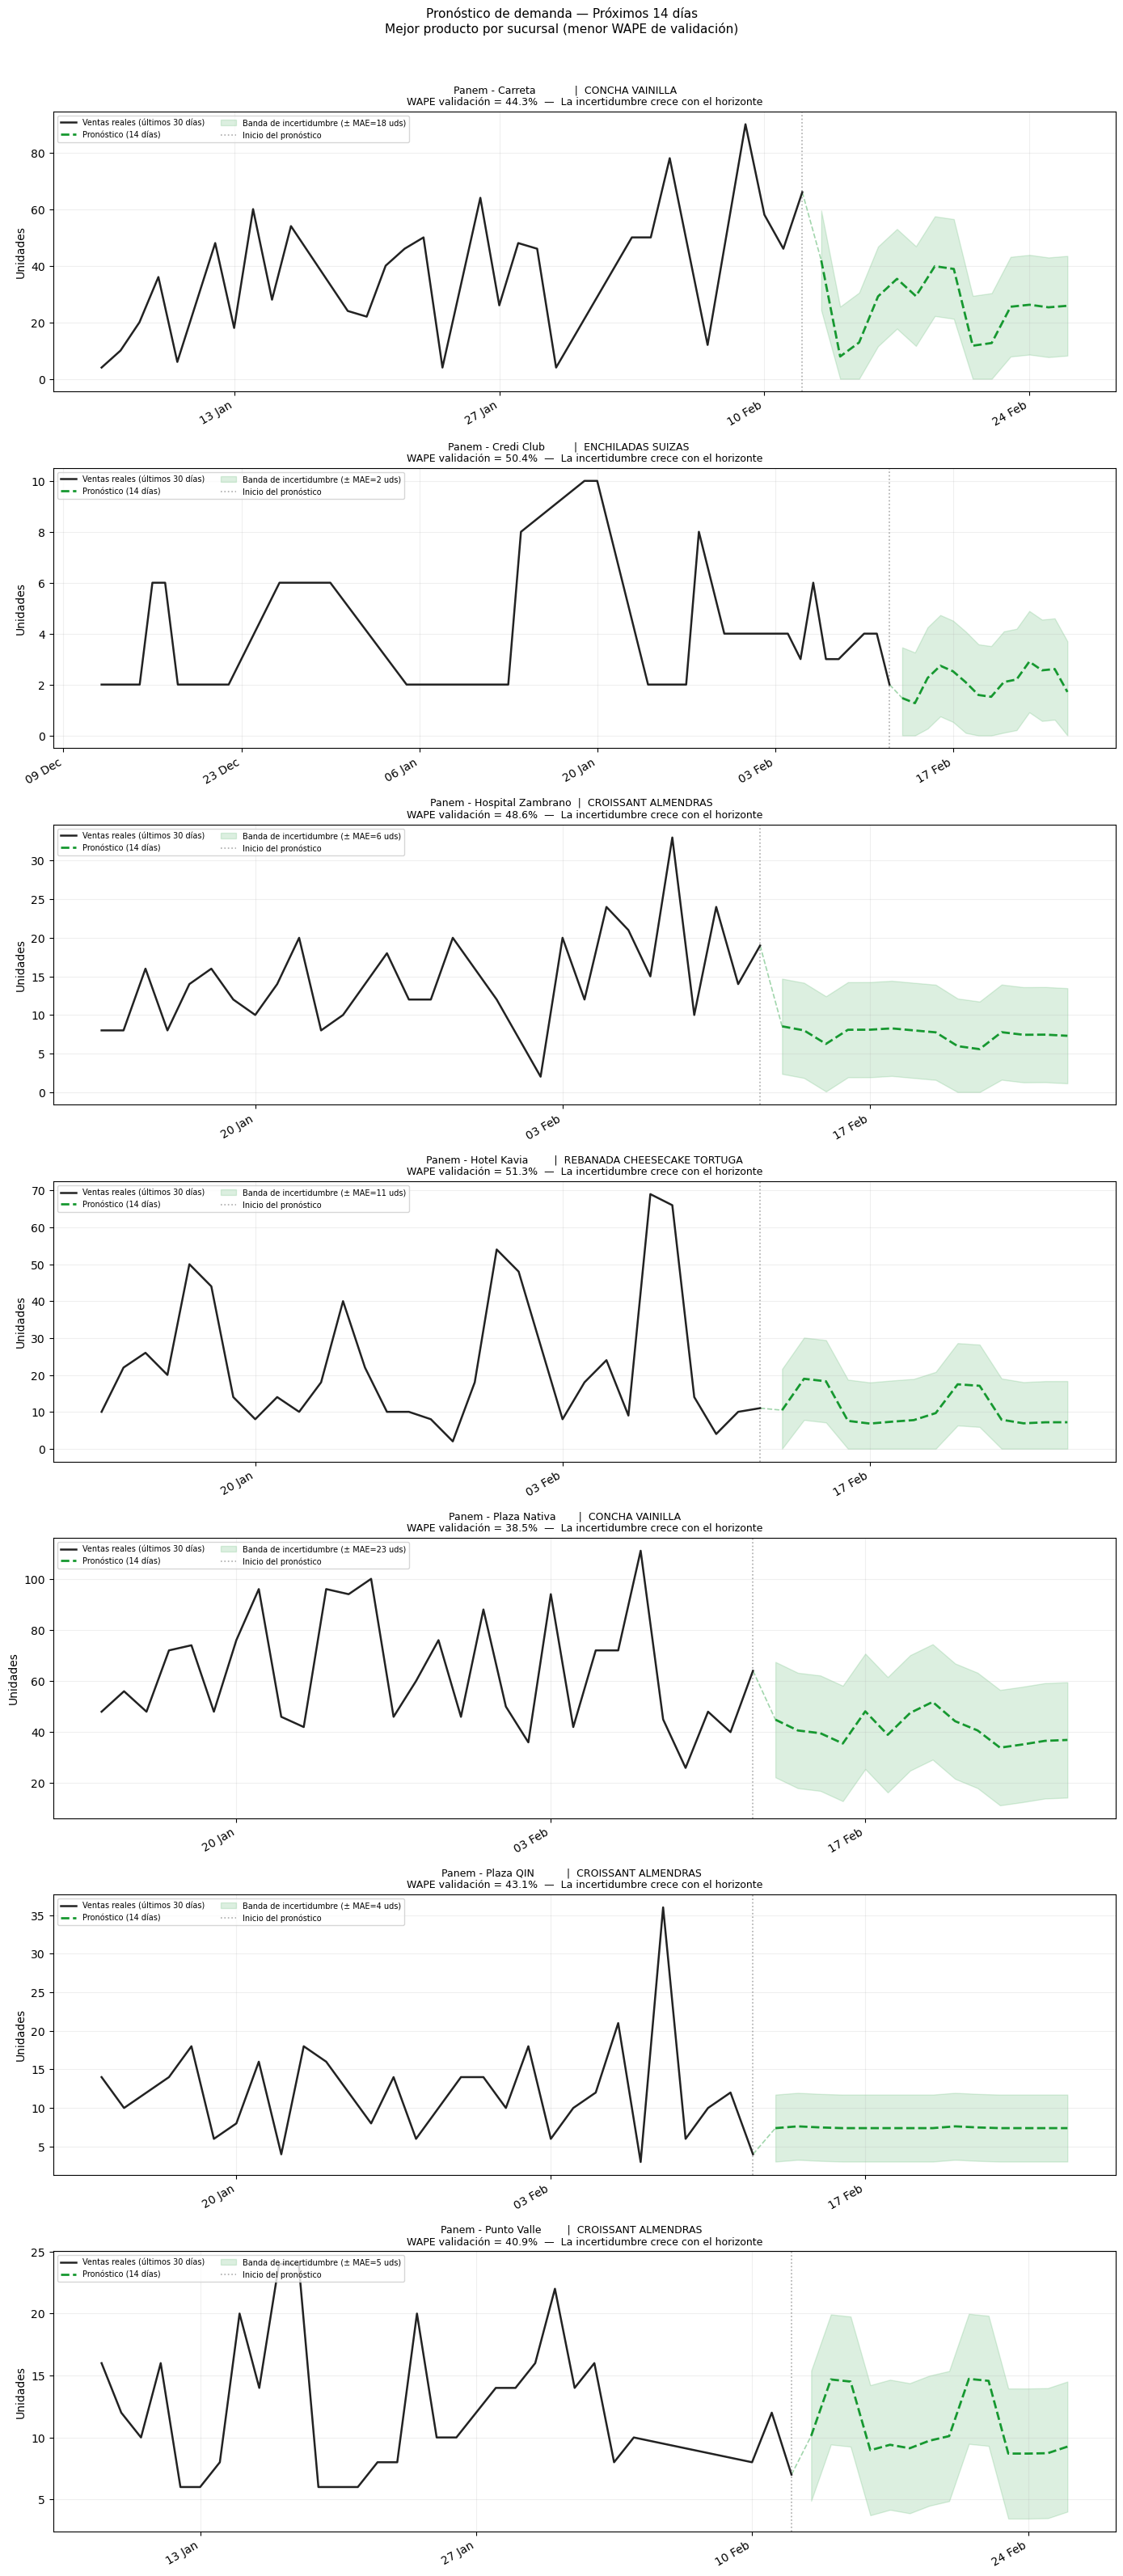

In [13]:
# ── Forecast visualization: recent actuals + future predictions ───────
# For each branch we show the product with the LOWEST validation WAPE
# (i.e., the most reliable model) to give the most trustworthy picture.
#
# Layout per subplot:
#   Black solid line  = last CONTEXT_DAYS of actual sales (historical context)
#   Green dashed line = next FORECAST_DAYS of predictions (the forecast)
#   Green shaded area = forecast uncertainty band (± validation MAE)
#   Grey dotted line  = boundary between past and future
#   Orange star       = days marked as holidays in the forecast window

CONTEXT_DAYS = 30   # how many days of past actuals to show alongside the forecast

# Identify the best-performing product per branch
best_pairs_fc = (
    results_df.sort_values("wape")
              .groupby("branch", as_index=False)
              .first()[["branch", "product", "mae", "wape"]]
)

n = len(best_pairs_fc)
fig, axes = plt.subplots(n, 1, figsize=(14, 4.5 * n))
if n == 1:
    axes = [axes]

last_actual_date = df["operating_date"].max()

for ax, (_, row) in zip(axes, best_pairs_fc.iterrows()):
    branch  = row["branch"]
    product = row["product"]
    mae_val = row["mae"]
    wape_val = row["wape"]

    # ── Historical context window ──────────────────────────────────
    hist_ctx = (
        df[(df["sucursal"] == branch) & (df["item"] == product)]
        .sort_values("operating_date")
        .tail(CONTEXT_DAYS)[["operating_date", "quantity"]]
    )

    # ── Future forecast ────────────────────────────────────────────
    fcast = (
        forecasts_df[
            (forecasts_df["branch"] == branch) &
            (forecasts_df["product"] == product)
        ]
        .sort_values("operating_date")
    )

    # ── Plot actual history ────────────────────────────────────────
    ax.plot(
        hist_ctx["operating_date"], hist_ctx["quantity"],
        color="#222222", linewidth=1.8, label=f"Ventas reales (últimos {CONTEXT_DAYS} días)",
        zorder=3
    )

    # ── Connector: last actual → first forecast ────────────────────
    ax.plot(
        [hist_ctx["operating_date"].iloc[-1], fcast["operating_date"].iloc[0]],
        [hist_ctx["quantity"].iloc[-1], fcast["predicted_quantity"].iloc[0]],
        color="#169830", linewidth=1.2, linestyle="--", alpha=0.4, zorder=2
    )

    # ── Plot forecast line ─────────────────────────────────────────
    ax.plot(
        fcast["operating_date"], fcast["predicted_quantity"],
        color="#169830", linewidth=2, linestyle="--",
        label=f"Pronóstico ({FORECAST_DAYS} días)", zorder=3
    )

    # ── Uncertainty band (± validation MAE around the forecast) ────
    # The band width is the MAE from the validation set — it represents
    # the average error the model made on days it had never seen before.
    # It is NOT a statistical confidence interval, but gives the owner
    # a realistic sense of how much the actual could deviate.
    ax.fill_between(
        fcast["operating_date"],
        (fcast["predicted_quantity"] - mae_val).clip(lower=0),
        fcast["predicted_quantity"] + mae_val,
        alpha=0.15, color="#169830",
        label=f"Banda de incertidumbre (± MAE={mae_val:.0f} uds)"
    )

    # ── Mark holiday dates in the forecast ────────────────────────
    holidays_fc = fcast[fcast["is_holiday"] == 1]
    if not holidays_fc.empty:
        ax.scatter(
            holidays_fc["operating_date"], holidays_fc["predicted_quantity"],
            marker="*", color="#d44000", s=140, zorder=5, label="Día festivo"
        )

    # ── Vertical boundary: past vs future ─────────────────────────
    ax.axvline(
        x=last_actual_date, color="#888888",
        linewidth=1.2, linestyle=":", alpha=0.7,
        label="Inicio del pronóstico"
    )

    ax.set_title(
        f"{branch}  |  {product}\n"
        f"WAPE validación = {wape_val:.1f}%  —  "
        f"La incertidumbre crece con el horizonte",
        fontsize=9
    )
    ax.set_ylabel("Unidades")
    ax.legend(fontsize=7, loc="upper left", ncol=2)
    ax.grid(alpha=0.2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.suptitle(
    f"Pronóstico de demanda — Próximos {FORECAST_DAYS} días\n"
    f"Mejor producto por sucursal (menor WAPE de validación)",
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()

In [14]:
# ── Stock recommendation pivot table ─────────────────────────────────
# Translates the forecast into an actionable planning table per branch.
#
# We add a safety buffer on top of the raw prediction. The buffer size
# is calibrated to the model's WAPE: a model with 50% WAPE has high
# uncertainty, so we pad more; a model with 40% WAPE pads less.
#
#   buffer_pct = min(wape / 100, 0.40)   → capped at 40% extra units
#   recommended_stock = ceil(predicted × (1 + buffer_pct))
#
# Using ceiling (not rounding) ensures we never recommend *less* than
# the prediction — for a café, running out of stock is worse than
# having a small surplus.

WAPE_LOOKUP = results_df.set_index(["branch", "product"])["wape"].to_dict()

def compute_recommended_stock(row):
    key = (row["branch"], row["product"])
    wape = WAPE_LOOKUP.get(key, 50.0)          # default 50% if model was skipped
    buffer_pct = min(wape / 100.0, 0.40)       # cap buffer at 40%
    return int(np.ceil(row["predicted_quantity"] * (1 + buffer_pct)))

forecasts_df["recommended_stock"] = forecasts_df.apply(compute_recommended_stock, axis=1)

# ── Print per-branch planning tables ─────────────────────────────────
print(f"{'='*70}")
print(f"  PANEM — Daily Stock Recommendation  |  Next {FORECAST_DAYS} days")
print(f"  Buffer = WAPE-adjusted (WAPE/100, capped at +40%)")
print(f"{'='*70}\n")

for branch in sorted(forecasts_df["branch"].unique()):
    branch_fc = forecasts_df[forecasts_df["branch"] == branch].copy()

    # Pivot: rows = dates, columns = products
    pivot = branch_fc.pivot_table(
        index=["operating_date", "day_name"],
        columns="product",
        values="recommended_stock",
        aggfunc="first"
    ).reset_index()
    pivot.columns.name = None
    pivot = pivot.rename(columns={"operating_date": "Fecha", "day_name": "Día"})

    # Flag holiday rows
    holiday_dates = set(
        branch_fc[branch_fc["is_holiday"] == 1]["operating_date"].dt.date
    )
    pivot["Fecha_str"] = pivot["Fecha"].dt.strftime("%Y-%m-%d")
    pivot["Día"] = pivot["Día"].str.capitalize()
    pivot["Festivo"] = pivot["Fecha"].dt.date.apply(
        lambda d: "★" if d in holiday_dates else ""
    )

    display_cols = ["Fecha_str", "Día", "Festivo"] + [
        c for c in pivot.columns if c not in ["Fecha", "Fecha_str", "Día", "Festivo"]
    ]

    print(f"\n{'─'*60}")
    print(f"  {branch}")
    print(f"{'─'*60}")
    display(pivot[display_cols].rename(columns={"Fecha_str": "Fecha"}).set_index("Fecha"))

print("\n★ = holiday day — demand patterns may differ from model predictions.")

  PANEM — Daily Stock Recommendation  |  Next 14 days
  Buffer = WAPE-adjusted (WAPE/100, capped at +40%)


────────────────────────────────────────────────────────────
  Panem - Carreta          
────────────────────────────────────────────────────────────


,Día,Festivo,CONCHA CHOCOLATE,CONCHA VAINILLA,GALLETA DE AVENA,MUFFIN BLUEBERRY,MUFFIN PLATANO VEGANO
Fecha,,,,,,,
2026-02-13,Viernes,,22,59,13,10,13
2026-02-14,Sábado,,12,12,7,5,5
2026-02-15,Domingo,,13,19,7,5,5
2026-02-16,Lunes,,23,41,11,8,10
2026-02-17,Martes,,23,50,11,9,11
2026-02-18,Miércoles,,23,41,11,8,10
2026-02-19,Jueves,,19,56,12,9,13
2026-02-20,Viernes,,20,55,12,10,11
2026-02-21,Sábado,,11,17,7,5,6



────────────────────────────────────────────────────────────
  Panem - Credi Club       
────────────────────────────────────────────────────────────


,Día,Festivo,CHILAQUILES PANEM,CONCHA CHOCOLATE,CONCHA UBER,CONCHA VAINILLA,ENCHILADAS SUIZAS
Fecha,,,,,,,
2026-01-27,Martes,,NaN,NaN,5.00,NaN,NaN
2026-01-28,Miércoles,,NaN,NaN,4.00,NaN,NaN
2026-01-29,Jueves,,NaN,NaN,4.00,NaN,NaN
2026-01-30,Viernes,,NaN,NaN,5.00,NaN,NaN
2026-01-31,Sábado,,NaN,NaN,5.00,NaN,NaN
2026-02-01,Domingo,,NaN,NaN,6.00,NaN,NaN
2026-02-02,Lunes,★,NaN,NaN,4.00,NaN,NaN
2026-02-03,Martes,,NaN,NaN,5.00,NaN,NaN
2026-02-04,Miércoles,,NaN,NaN,5.00,NaN,NaN



────────────────────────────────────────────────────────────
  Panem - Hospital Zambrano
────────────────────────────────────────────────────────────


...


────────────────────────────────────────────────────────────
  Panem - Plaza QIN        
────────────────────────────────────────────────────────────


,Día,Festivo,CHILAQUILES PANEM,CONCHA CHOCOLATE,CONCHA VAINILLA,CROISSANT ALMENDRAS
Fecha,,,,,,
2026-02-13,Viernes,,13,26,74,11
2026-02-14,Sábado,,16,26,70,11
2026-02-15,Domingo,,19,28,63,11
2026-02-16,Lunes,,10,23,55,11
2026-02-17,Martes,,12,27,76,11
2026-02-18,Miércoles,,13,27,63,11
2026-02-19,Jueves,,13,29,75,11
2026-02-20,Viernes,,13,28,92,11
2026-02-21,Sábado,,17,28,80,11



────────────────────────────────────────────────────────────
  Panem - Punto Valle      
────────────────────────────────────────────────────────────


,Día,Festivo,CHILAQUILES PANEM,CONCHA CHOCOLATE,CONCHA VAINILLA,CROISSANT ALMENDRAS,PAIN AU CHOCOLAT
Fecha,,,,,,,
2026-02-13,Viernes,,23,31,67,15,12
2026-02-14,Sábado,,30,45,70,21,14
2026-02-15,Domingo,,30,41,69,21,14
2026-02-16,Lunes,,15,16,47,13,10
2026-02-17,Martes,,16,15,54,14,11
2026-02-18,Miércoles,,17,14,46,13,11
2026-02-19,Jueves,,19,22,55,14,11
2026-02-20,Viernes,,20,38,63,15,11
2026-02-21,Sábado,,29,55,68,21,16



★ = holiday day — demand patterns may differ from model predictions.


In [15]:
# ── Save forecast to CSV ──────────────────────────────────────────────
# The CSV has one row per (branch, product, date) and includes all columns
# needed for the café owner: predicted units, day name, temperature proxy,
# holiday flag, and the recommended stock order (prediction + safety buffer).

forecast_out_path = os.path.join(OUTPUT_DIR, "future_forecast.csv")
forecasts_df.to_csv(forecast_out_path, index=False)
print(f"Forecast CSV saved → {forecast_out_path}")
print(f"Shape: {forecasts_df.shape[0]} rows × {forecasts_df.shape[1]} columns")
print(f"\nFirst 10 rows:")
display(forecasts_df.head(10))

# ── Optional: download in Colab ───────────────────────────────────────
try:
    from google.colab import files
    files.download(forecast_out_path)
    print("Download triggered.")
except ImportError:
    print("(Not running in Colab — file saved locally only.)")

Forecast CSV saved → /Users/diego/Documents/ChallengeAI/models/xgboost/predictions/future_forecast.csv
Shape: 476 rows × 9 columns

First 10 rows:


,operating_date,branch,product,predicted_quantity,tavg_forecast,is_holiday,holiday_type_enc,day_name,recommended_stock
0,2026-02-13,Panem - Carreta,CONCHA CHOCOLATE,15.24,13.80,0,0,viernes,22
1,2026-02-14,Panem - Carreta,CONCHA CHOCOLATE,8.31,14.90,0,0,sábado,12
2,2026-02-15,Panem - Carreta,CONCHA CHOCOLATE,8.68,19.00,0,0,domingo,13
3,2026-02-16,Panem - Carreta,CONCHA CHOCOLATE,16.33,17.40,0,0,lunes,23
4,2026-02-17,Panem - Carreta,CONCHA CHOCOLATE,15.90,12.80,0,0,martes,23
5,2026-02-18,Panem - Carreta,CONCHA CHOCOLATE,15.91,15.70,0,0,miércoles,23
6,2026-02-19,Panem - Carreta,CONCHA CHOCOLATE,13.37,11.60,0,0,jueves,19
7,2026-02-20,Panem - Carreta,CONCHA CHOCOLATE,14.15,12.80,0,0,viernes,20
8,2026-02-21,Panem - Carreta,CONCHA CHOCOLATE,7.70,15.40,0,0,sábado,11
9,2026-02-22,Panem - Carreta,CONCHA CHOCOLATE,7.60,19.20,0,0,domingo,11


(Not running in Colab — file saved locally only.)


In [ ]:
#import shutil
#from google.colab import files

#zip_path = "/content/xgboost_predictions.zip"
#shutil.make_archive("/content/xgboost_predictions", "zip", "/content/predictions", "xgboost")
#files.download(zip_path)
#print("Done — check your Downloads folder for xgboost_predictions.zip")